# Robustez temporal y selección de finalistas

El notebook 04 comparó familias bajo una validación acumulada. LightGBM logró la mayor ganancia, CatBoost el mejor orden y calibración, y XGBoost quedó cerca.

En esta primera parte cambio una sola decisión: cuánta historia recibe el modelo. Comparo el train acumulado con una ventana móvil de 17 días. Mantengo los mismos parámetros, features, umbral y períodos de validación para que cualquier diferencia provenga de la historia usada para entrenar.

El test final permanece bloqueado.

## 1. Setup

In [1]:
from itertools import combinations
from pathlib import Path
import importlib
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams["figure.figsize"] = (8, 3.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True
plt.rcParams["grid.alpha"] = 0.3

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.features as features_module
import src.modeling as modeling_module
import src.validation as validation_module
importlib.reload(features_module)
importlib.reload(modeling_module)
importlib.reload(validation_module)

from src.business import ganancia_por_operacion, ganancia_total, umbral_aprobacion
from src.data import TARGET, DEFAULT_DATA_PATH, DEFAULT_PROCESSED_DIR, cargar_datos, convertir_fecha
from src.evaluation import metricas_decision, metricas_probabilidad
from src.features import crear_features_arbol, crear_features_logistica
from src.modeling import ajustar_y_predecir_arbol, crear_pipeline_logistica
from src.validation import (
    crear_folds_ventana,
    mascaras_desarrollo_test,
    mascaras_fold,
    validar_folds,
)

UMBRAL_ECONOMICO = umbral_aprobacion()
SEMILLAS = [42, 43, 44]
FOLDS_EXTERNOS = [2, 3]
DIAS_VENTANA = 17

FOLDS_PATH = DEFAULT_PROCESSED_DIR / "validation_folds.csv"
PARAMS_PATH = DEFAULT_PROCESSED_DIR / "mejores_params_arbol.json"

c:\Users\cfede\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = cargar_datos(DEFAULT_DATA_PATH)
fecha = convertir_fecha(df["fecha"])
y = df[TARGET]
monto = df["monto"]
fecha_origen = fecha.min().normalize()

folds_acumulados = pd.read_csv(
    FOLDS_PATH,
    parse_dates=["train_start", "train_end", "validation_start", "validation_end"],
)
folds_ventana = crear_folds_ventana(folds_acumulados, dias_train=DIAS_VENTANA)
_, es_test = mascaras_desarrollo_test(fecha)
validar_folds(fecha, folds_acumulados, es_test)
validar_folds(fecha, folds_ventana, es_test)

with PARAMS_PATH.open(encoding="utf-8") as archivo:
    params_guardados = json.load(archivo)

X_logistica = {
    "sin_score": crear_features_logistica(df, incluir_score=False, fecha_origen=fecha_origen),
    "con_score": crear_features_logistica(df, incluir_score=True, fecha_origen=fecha_origen),
}
X_arbol = {
    "sin_score": crear_features_arbol(df, incluir_score=False, fecha_origen=fecha_origen),
    "con_score": crear_features_arbol(df, incluir_score=True, fecha_origen=fecha_origen),
}

print(f"Desarrollo: {(~es_test).sum():,} filas")
print(f"Test bloqueado: {es_test.sum():,} filas")
print(f"Umbral económico: {UMBRAL_ECONOMICO:.2f}")

Desarrollo: 121,014 filas
Test bloqueado: 28,986 filas
Umbral económico: 0.20


## 2. Qué cambia con la ventana

La validación sigue usando semanas completas. Lo único que cambia es el inicio del train:

- En acumulado, todos los folds comienzan el primer día.
- En ventana, cada fold conserva los 17 días anteriores a su validación.

El valor 17 no se busca probando muchas alternativas. Coincide con la cantidad de historia del train inicial y permite comparar tamaños parecidos.

Semana 1, Semana 2 y Semana 3 siguen identificando las mismas validaciones del notebook 2. Para la comparación externa uso Semana 2 y Semana 3, Semana 1 ya participó en la elección de parámetros para Semana 2.

In [3]:
def resumir_folds(nombre, folds):
    filas = []
    for _, fold in folds.iterrows():
        train, validacion = mascaras_fold(fecha, fold)
        filas.append({
            "estrategia": nombre,
            "semana": f"Semana {int(fold['fold'])}",
            "inicio_train": fold["train_start"].date(),
            "fin_train": (fold["train_end"] - pd.Timedelta(days=1)).date(),
            "inicio_validacion": fold["validation_start"].date(),
            "fin_validacion": (fold["validation_end"] - pd.Timedelta(days=1)).date(),
            "n_train": int(train.sum()),
            "n_validacion": int(validacion.sum()),
            "fraudes_train": int(y.loc[train].sum()),
        })
    return pd.DataFrame(filas)

mapa_folds = pd.concat([
    resumir_folds("acumulado", folds_acumulados),
    resumir_folds("ventana", folds_ventana),
], ignore_index=True)
mapa_folds

,estrategia,semana,inicio_train,fin_train,inicio_validacion,fin_validacion,n_train,n_validacion,fraudes_train
0,acumulado,Semana 1,2020-03-08,2020-03-24,2020-03-25,2020-03-31,60424,16537,2877
1,acumulado,Semana 2,2020-03-08,2020-03-31,2020-04-01,2020-04-07,76961,20282,3877
2,acumulado,Semana 3,2020-03-08,2020-04-07,2020-04-08,2020-04-14,97243,23771,5020
3,ventana,Semana 1,2020-03-08,2020-03-24,2020-03-25,2020-03-31,60424,16537,2877
4,ventana,Semana 2,2020-03-15,2020-03-31,2020-04-01,2020-04-07,52370,20282,2688
5,ventana,Semana 3,2020-03-22,2020-04-07,2020-04-08,2020-04-14,47512,23771,2694


## 3. Modelos que entran a la prueba

Con score comparo la regresión logística, XGBoost, LightGBM y CatBoost. 

Sin score comparo solamente la regresión logística y CatBoost. 

Uso los parámetros ya elegidos por Optuna para aislar el efecto de cambiar la historia de entrenamiento.

In [4]:
from functools import partial

from src.evaluation import obtener_params as _obtener_params
from src.evaluation import registrar_prediccion as _registrar_prediccion

obtener_params = partial(_obtener_params, params_guardados)
registrar_prediccion = partial(
    _registrar_prediccion, y=y, monto=monto, umbral=UMBRAL_ECONOMICO
)

## 4. Evaluación acumulada y con ventana

Cada modelo se evalúa sobre las mismas Semanas 2 y 3. Los árboles se repiten con tres semillas. La regresión logística es determinística para este pipeline

Las probabilidades se usan sin calibración porque el notebook anterior mostró cambios mínimos y mezclados. El umbral permanece fijo en 20%.

In [5]:
resultados = []
predicciones = []
estrategias = {
    "acumulado": folds_acumulados,
    "ventana": folds_ventana,
}

for estrategia, folds_actuales in estrategias.items():
    for outer_fold in FOLDS_EXTERNOS:
        fold = folds_actuales.loc[folds_actuales["fold"].eq(outer_fold)].iloc[0]
        train, validacion = mascaras_fold(fecha, fold)
        print(f"{estrategia} | Semana {outer_fold}")

        for escenario in ["con_score", "sin_score"]:
            modelo_logistico = crear_pipeline_logistica(
                incluir_score=escenario == "con_score",
                semilla=SEMILLAS[0],
            )
            modelo_logistico.fit(
                X_logistica[escenario].loc[train], y.loc[train]
            )
            probabilidad = modelo_logistico.predict_proba(
                X_logistica[escenario].loc[validacion]
            )[:, 1]
            fila, detalle = registrar_prediccion(
                probabilidad, validacion, estrategia, escenario,
                "logistica", outer_fold, 0,
            )
            resultados.append(fila)
            predicciones.append(detalle)

        candidatos_arbol = [
            ("xgboost", "con_score"),
            ("lightgbm", "con_score"),
            ("catboost", "con_score"),
            ("catboost", "sin_score"),
        ]
        for modelo, escenario in candidatos_arbol:
            params = obtener_params(modelo, escenario, outer_fold)
            for repeticion, semilla in enumerate(SEMILLAS):
                probabilidad = ajustar_y_predecir_arbol(
                    modelo,
                    params,
                    X_arbol[escenario].loc[train],
                    y.loc[train],
                    X_arbol[escenario].loc[validacion],
                    semilla=semilla,
                )
                fila, detalle = registrar_prediccion(
                    probabilidad, validacion, estrategia, escenario,
                    modelo, outer_fold, repeticion,
                )
                resultados.append(fila)
                predicciones.append(detalle)

resultados = pd.DataFrame(resultados)
predicciones = pd.concat(predicciones, ignore_index=True)
resultados.head()

acumulado | Semana 2


c:\Users\cfede\miniconda3\Lib\site-packages\xgboost\core.py:553: UserWarning: [23:21:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


acumulado | Semana 3
ventana | Semana 2
ventana | Semana 3


,estrategia,escenario,modelo,outer_fold,repeticion,ganancia,tasa_aprobacion,fraudes_rechazados,legitimas_rechazadas,roc_auc,pr_auc,brier,prevalencia,pr_auc_norm,brier_skill
0,acumulado,con_score,logistica,2,0,"136,923.5675",0.9233,0.4733,0.0530,0.8399,0.3732,0.0430,0.0564,0.3358,0.1909
1,acumulado,sin_score,logistica,2,0,"133,413.2525",0.9203,0.4628,0.0568,0.8389,0.3383,0.0445,0.0564,0.2988,0.1627
2,acumulado,con_score,xgboost,2,0,"138,307.6600",0.9247,0.5267,0.0484,0.8886,0.4878,0.0386,0.0564,0.4572,0.2742
3,acumulado,con_score,xgboost,2,1,"138,537.8875",0.9243,0.5284,0.0487,0.8877,0.4851,0.0387,0.0564,0.4543,0.2714
4,acumulado,con_score,xgboost,2,2,"136,384.4050",0.9237,0.5319,0.0491,0.8866,0.4858,0.0387,0.0564,0.4551,0.2719


## 5. Resultado general

Primero sumo la ganancia de las dos semanas dentro de cada repetición. Después promedio entre semillas. De esta forma una semilla no cuenta como si fuera un período temporal adicional.

Una aclaración sobre cómo se agregan las métricas, igual que en el notebook 4: la ganancia se suma entre folds y ROC-AUC se promedia porque su referencia de 0,5 no depende directamente de la prevalencia. Para PR-AUC y Brier uso versiones normalizadas contra la referencia de cada fold, junto con los valores crudos.

In [6]:
por_repeticion = (
    resultados.groupby(["estrategia", "escenario", "modelo", "repeticion"])
    .agg(
        ganancia=("ganancia", "sum"),
        tasa_aprobacion=("tasa_aprobacion", "mean"),
        fraudes_rechazados=("fraudes_rechazados", "mean"),
        legitimas_rechazadas=("legitimas_rechazadas", "mean"),
        pr_auc_norm=("pr_auc_norm", "mean"),
        roc_auc=("roc_auc", "mean"),
        brier_skill=("brier_skill", "mean"),
    )
    .reset_index()
)

resumen = (
    por_repeticion.groupby(["estrategia", "escenario", "modelo"])
    .agg(
        ganancia=("ganancia", "mean"),
        variacion_semillas=("ganancia", "std"),
        tasa_aprobacion=("tasa_aprobacion", "mean"),
        fraudes_rechazados=("fraudes_rechazados", "mean"),
        legitimas_rechazadas=("legitimas_rechazadas", "mean"),
        pr_auc_norm=("pr_auc_norm", "mean"),
        roc_auc=("roc_auc", "mean"),
        brier_skill=("brier_skill", "mean"),
    )
    .fillna({"variacion_semillas": 0.0})
    .sort_values(["escenario", "estrategia", "ganancia"], ascending=[True, True, False])
)
resumen

ganancia  variacion_semillas  \
estrategia escenario modelo                                       
acumulado  con_score lightgbm  307,575.7083          1,073.9025   
                     catboost  306,470.1367          2,411.9986   
                     xgboost   305,045.8792            845.4848   
                     logistica 301,890.9100              0.0000   
ventana    con_score xgboost   305,894.8225          2,776.4328   
                     catboost  305,675.3092            778.2275   
                     lightgbm  301,285.7492            248.4550   
                     logistica 299,716.4325              0.0000   
acumulado  sin_score catboost  297,574.8992            442.7794   
                     logistica 296,765.8375              0.0000   
ventana    sin_score catboost  297,764.6417          2,222.9605   
                     logistica 294,818.4700              0.0000   

                                tasa_aprobacion  fraudes_rechazados  \
estrategia escenario modelo                                           
acumulado  con_score lightgbm            0.9365              0.4903   
                     catboost            0.9373              0.5005   
                     xgboost             0.9277              0.5278   
                     logistica           0.9252              0.4822   
ventana    con_score xgboost             0.9302              0.5210   
                     catboost            0.9380              0.4986   
                     lightgbm            0.9431              0.4622   
                     logistica           0.9205              0.4972   
acumulado  sin_score catboost            0.9346              0.4549   
                     logistica           0.9230              0.4661   
ventana    sin_score catboost            0.9348              0.4502   
                     logistica           0.9198              0.4720   

                                legitimas_rechazadas  pr_auc_norm  roc_auc  \
estrategia escenario modelo                                                  
acumulado  con_score lightgbm                 0.0390       0.4363   0.8776   
                     catboost                 0.0375       0.4571   0.8885   
                     xgboost                  0.0461       0.4520   0.8877   
                     logistica                0.0514       0.3411   0.8423   
ventana    con_score xgboost                  0.0439       0.4472   0.8856   
                     catboost                 0.0369       0.4512   0.8877   
                     lightgbm                 0.0336       0.4275   0.8741   
                     logistica                0.0555       0.3413   0.8419   
acumulado  sin_score catboost                 0.0431       0.3769   0.8537   
                     logistica                0.0546       0.3033   0.8411   
ventana    sin_score catboost                 0.0431       0.3666   0.8518   
                     logistica                0.0577       0.3033   0.8406   

                                brier_skill  
estrategia escenario modelo                  
acumulado  con_score lightgbm        0.2595  
                     catboost        0.2774  
                     xgboost         0.2698  
                     logistica       0.1929  
ventana    con_score xgboost         0.2676  
                     catboost        0.2727  
                     lightgbm        0.2516  
                     logistica       0.1893  
acumulado  sin_score catboost        0.2165  
                     logistica       0.1645  
ventana    sin_score catboost        0.2085  
                     logistica       0.1620

In [7]:
columnas = ["escenario", "modelo", "ganancia", "pr_auc_norm", "brier_skill"]
acumulado = resumen.xs("acumulado", level="estrategia").reset_index()[columnas]
ventana = resumen.xs("ventana", level="estrategia").reset_index()[columnas]

comparacion = acumulado.merge(
    ventana,
    on=["escenario", "modelo"],
    suffixes=("_acumulado", "_ventana"),
)
comparacion["cambio_ganancia"] = (
    comparacion["ganancia_ventana"] - comparacion["ganancia_acumulado"]
)
comparacion["cambio_pr_auc_norm"] = (
    comparacion["pr_auc_norm_ventana"] - comparacion["pr_auc_norm_acumulado"]
)
comparacion["cambio_brier_skill"] = (
    comparacion["brier_skill_ventana"] - comparacion["brier_skill_acumulado"]
)
comparacion.sort_values(
    ["escenario", "ganancia_ventana"], ascending=[True, False]
)

,escenario,modelo,ganancia_acumulado,pr_auc_norm_acumulado,brier_skill_acumulado,ganancia_ventana,pr_auc_norm_ventana,brier_skill_ventana,cambio_ganancia,cambio_pr_auc_norm,cambio_brier_skill
2,con_score,xgboost,"305,045.8792",0.4520,0.2698,"305,894.8225",0.4472,0.2676,848.9433,-0.0048,-0.0023
1,con_score,catboost,"306,470.1367",0.4571,0.2774,"305,675.3092",0.4512,0.2727,-794.8275,-0.0059,-0.0047
0,con_score,lightgbm,"307,575.7083",0.4363,0.2595,"301,285.7492",0.4275,0.2516,"-6,289.9592",-0.0088,-0.0079
3,con_score,logistica,"301,890.9100",0.3411,0.1929,"299,716.4325",0.3413,0.1893,"-2,174.4775",0.0002,-0.0036
4,sin_score,catboost,"297,574.8992",0.3769,0.2165,"297,764.6417",0.3666,0.2085,189.7425,-0.0103,-0.0080
5,sin_score,logistica,"296,765.8375",0.3033,0.1645,"294,818.4700",0.3033,0.1620,"-1,947.3675",0.0001,-0.0025


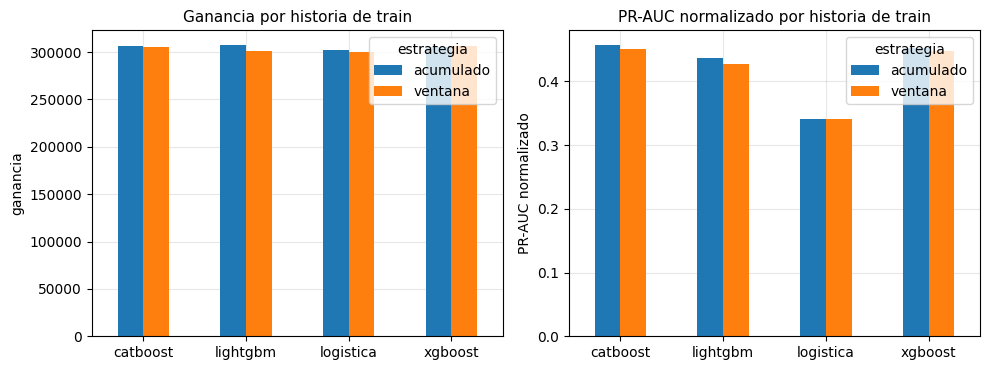

In [8]:
datos_plot = resumen.xs("con_score", level="escenario").reset_index()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

datos_plot.pivot(index="modelo", columns="estrategia", values="ganancia").plot.bar(
    ax=axes[0], rot=0
)
axes[0].set_title("Ganancia por historia de train", fontsize=11)
axes[0].set_ylabel("ganancia")
axes[0].set_xlabel("")

datos_plot.pivot(index="modelo", columns="estrategia", values="pr_auc_norm").plot.bar(
    ax=axes[1], rot=0
)
axes[1].set_title("PR-AUC normalizado por historia de train", fontsize=11)
axes[1].set_ylabel("PR-AUC normalizado")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

## 6. La diferencia por semana

La comparación anterior fue sobre el total de las dos semanas, y un total puede esconder que una estrategia mejora una semana y empeora la otra. Acá abro esa misma comparación por fold: promedio las semillas dentro de cada semana y miro la ventana contra el acumulado semana por semana, sobre exactamente las mismas operaciones.

In [9]:
por_fold = (
    resultados.groupby(["estrategia", "escenario", "modelo", "outer_fold"])
    .agg(
        ganancia=("ganancia", "mean"),
        pr_auc=("pr_auc", "mean"),
        brier=("brier", "mean"),
    )
    .reset_index()
)

ganancia_fold = por_fold.pivot(
    index=["escenario", "modelo", "outer_fold"],
    columns="estrategia",
    values="ganancia",
).reset_index()
ganancia_fold["cambio_ventana"] = (
    ganancia_fold["ventana"] - ganancia_fold["acumulado"]
)
ganancia_fold["semana"] = "Semana " + ganancia_fold["outer_fold"].astype(str)
ganancia_fold.sort_values(["escenario", "modelo", "outer_fold"])

estrategia,escenario,modelo,outer_fold,acumulado,ventana,cambio_ventana,semana
0,con_score,catboost,2,"138,346.5517","138,112.8675",-233.6842,Semana 2
1,con_score,catboost,3,"168,123.5850","167,562.4417",-561.1433,Semana 3
2,con_score,lightgbm,2,"137,412.1658","135,504.7842","-1,907.3817",Semana 2
3,con_score,lightgbm,3,"170,163.5425","165,780.9650","-4,382.5775",Semana 3
4,con_score,logistica,2,"136,923.5675","134,687.0125","-2,236.5550",Semana 2
5,con_score,logistica,3,"164,967.3425","165,029.4200",62.0775,Semana 3
6,con_score,xgboost,2,"137,743.3175","138,571.3467",828.0292,Semana 2
7,con_score,xgboost,3,"167,302.5617","167,323.4758",20.9142,Semana 3
8,sin_score,catboost,2,"132,138.2283","131,631.6333",-506.5950,Semana 2
9,sin_score,catboost,3,"165,436.6708","166,133.0083",696.3375,Semana 3


## 7. Cuándo los modelos deciden distinto

Dos modelos con métricas parecidas pueden aprobar operaciones diferentes. Esa diferencia importa para una mezcla futura. Uso la semilla 42 y mido qué proporción de decisiones no coincide entre cada par de modelos con score.

In [10]:
filas_desacuerdo = []
base = predicciones.query("escenario == 'con_score' and repeticion == 0")

for (estrategia, outer_fold), grupo in base.groupby(["estrategia", "outer_fold"]):
    modelos = sorted(grupo["modelo"].unique())
    for modelo_a, modelo_b in combinations(modelos, 2):
        a = grupo.loc[grupo["modelo"].eq(modelo_a), ["row_id", "aprobar", "probabilidad"]]
        b = grupo.loc[grupo["modelo"].eq(modelo_b), ["row_id", "aprobar", "probabilidad"]]
        par = a.merge(b, on="row_id", suffixes=("_a", "_b"))
        filas_desacuerdo.append({
            "estrategia": estrategia,
            "semana": f"Semana {outer_fold}",
            "modelo_a": modelo_a,
            "modelo_b": modelo_b,
            "decisiones_distintas": par["aprobar_a"].ne(par["aprobar_b"]).mean(),
            "correlacion_probabilidades": par[["probabilidad_a", "probabilidad_b"]].corr().iloc[0, 1],
        })

desacuerdos = pd.DataFrame(filas_desacuerdo)
desacuerdos.sort_values(
    ["estrategia", "decisiones_distintas"], ascending=[True, False]
)

,estrategia,semana,modelo_a,modelo_b,decisiones_distintas,correlacion_probabilidades
11,acumulado,Semana 3,logistica,xgboost,0.0497,0.8063
5,acumulado,Semana 2,logistica,xgboost,0.0476,0.8290
7,acumulado,Semana 3,catboost,logistica,0.0436,0.8337
9,acumulado,Semana 3,lightgbm,logistica,0.0435,0.8418
3,acumulado,Semana 2,lightgbm,logistica,0.0427,0.8439
1,acumulado,Semana 2,catboost,logistica,0.0408,0.8407
4,acumulado,Semana 2,lightgbm,xgboost,0.0373,0.9136
10,acumulado,Semana 3,lightgbm,xgboost,0.0313,0.9180
0,acumulado,Semana 2,catboost,lightgbm,0.0278,0.9370
6,acumulado,Semana 3,catboost,lightgbm,0.0244,0.9409


## 8. Segundo filtro

La comparación entre acumulado y ventana mide cuánto depende cada candidato del historial usado para entrenar:

- LightGBM pierde 6.290 con la ventana (de 307.576 a 301.286). La caída aparece en las dos semanas y borra su ventaja frente a la logística: su liderazgo en ganancia dependía de conservar toda la historia.
- CatBoost se mantiene estable: queda en 306.470 con el acumulado y 305.675 con la ventana, una diferencia de 795, menor que la variación entre semillas del acumulado. Conserva además el mejor orden y calidad probabilística (PR-AUC normalizado y Brier Skill Score).
- XGBoost mejora 849 con la ventana y llega a 305.895, muy cerca de CatBoost.
- La regresión logística baja 2.174 y continúa como referencia simple.

Por estabilidad, CatBoost y XGBoost son los dos árboles finalistas con score. LightGBM queda fuera.

Sin score, CatBoost supera a la logística tanto en acumulado como en ventana. Continúa como alternativa, pero no compite contra los finalistas con score.

## 9. Profundización de los finalistas

Sobre CatBoost y XGBoost pruebo dos cambios: features de frecuencia para j y una mezcla de probabilidades. Ambos se evalúan con ventana de 17 días y los hiperparámetros ya elegidos, cambiando una sola cosa por vez. Sólo se volvería a optimizar si alguna variante muestra una mejora estable.

### 9.1. Frecuencia y rareza de j

Agrego tres features calculadas sólo con train:

- **j_frecuencia:** cantidad de apariciones.
- **j_frecuencia_relativa:** frecuencia dividida por el tamaño del train.
- **j_es_rara:** indica menos de 20 apariciones.

Las categorías nuevas reciben frecuencia 0 y se marcan como raras. También agrego **cantidad_faltantes**. Comparo este bloque contra las features base sin usar target ni información de validación.

In [11]:
resultados_features = []

for outer_fold in FOLDS_EXTERNOS:
    fold = folds_ventana.loc[folds_ventana["fold"].eq(outer_fold)].iloc[0]
    train, validacion = mascaras_fold(fecha, fold)

    for modelo in ["xgboost", "catboost"]:
        params = obtener_params(modelo, "con_score", outer_fold)
        for repeticion, semilla in enumerate(SEMILLAS):
            probabilidad = ajustar_y_predecir_arbol(
                modelo,
                params,
                X_arbol["con_score"].loc[train],
                y.loc[train],
                X_arbol["con_score"].loc[validacion],
                semilla=semilla,
                usar_features_dirigidas=True,
            )
            fila, _ = registrar_prediccion(
                probabilidad, validacion, "ventana_features", "con_score",
                modelo, outer_fold, repeticion,
            )
            resultados_features.append(fila)

resultados_features = pd.DataFrame(resultados_features)
resultados_features.head()

,estrategia,escenario,modelo,outer_fold,repeticion,ganancia,tasa_aprobacion,fraudes_rechazados,legitimas_rechazadas,roc_auc,pr_auc,brier,prevalencia,pr_auc_norm,brier_skill
0,ventana_features,con_score,xgboost,2,0,"137,580.3100",0.9279,0.5232,0.0451,0.8867,0.4789,0.0389,0.0564,0.4478,0.2677
1,ventana_features,con_score,xgboost,2,1,"137,530.2475",0.9280,0.5179,0.0454,0.8851,0.4839,0.0388,0.0564,0.4530,0.2706
2,ventana_features,con_score,xgboost,2,2,"136,266.4275",0.9242,0.5311,0.0486,0.8853,0.4819,0.0389,0.0564,0.4510,0.2679
3,ventana_features,con_score,catboost,2,0,"136,129.4700",0.9339,0.4943,0.0405,0.8852,0.4824,0.0388,0.0564,0.4515,0.2711
4,ventana_features,con_score,catboost,2,1,"134,944.2750",0.9342,0.4943,0.0402,0.8848,0.4817,0.0388,0.0564,0.4508,0.2706


In [12]:
base_finalistas = resultados.query(
    "estrategia == 'ventana' and escenario == 'con_score' "
    "and modelo in ['xgboost', 'catboost']"
).copy()
base_finalistas["version"] = "base"
comparacion_features = resultados_features.copy()
comparacion_features["version"] = "frecuencia_j"

detalle_features = pd.concat(
    [base_finalistas, comparacion_features], ignore_index=True
)
por_repeticion_features = (
    detalle_features.groupby(["version", "modelo", "repeticion"])
    .agg(
        ganancia=("ganancia", "sum"),
        pr_auc_norm=("pr_auc_norm", "mean"),
        brier_skill=("brier_skill", "mean"),
    )
    .reset_index()
)
resumen_features = (
    por_repeticion_features.groupby(["version", "modelo"])
    .agg(
        ganancia=("ganancia", "mean"),
        variacion_semillas=("ganancia", "std"),
        pr_auc_norm=("pr_auc_norm", "mean"),
        brier_skill=("brier_skill", "mean"),
    )
)
resumen_features

ganancia  variacion_semillas  pr_auc_norm  \
version      modelo                                                   
base         catboost 305,675.3092            778.2275       0.4512   
             xgboost  305,894.8225          2,776.4328       0.4472   
frecuencia_j catboost 301,247.8400          1,788.3125       0.4499   
             xgboost  303,581.0325          1,222.2897       0.4457   

                       brier_skill  
version      modelo                 
base         catboost       0.2727  
             xgboost        0.2676  
frecuencia_j catboost       0.2727  
             xgboost        0.2661

La frecuencia de j no aporta una mejora. La ganancia baja en CatBoost y en XGBoost. El PR-AUC normalizado también disminuye en ambos, mientras que el Brier Skill Score queda prácticamente igual. La menor variación entre semillas de XGBoost no compensa esa pérdida.

Por lo tanto, estas variables se descartan y los experimentos siguientes continúan con las features base.

### 9.2. Mezcla de CatBoost y XGBoost

Combino sus probabilidades con un promedio ponderado:

$$
p_{final} = w\,p_{catboost} + (1-w)\,p_{xgboost}
$$

El peso se elige en folds internos entre 0 y 1, en pasos de 0,1, maximizando ganancia al umbral de 0,20. Luego se aplica al fold externo. Los extremos permiten elegir cualquiera de los modelos sin mezcla.

In [13]:
ALPHAS = np.linspace(0, 1, 11)
resultados_mezcla = []
seleccion_mezcla = []

tareas = [
    (outer_fold, repeticion, semilla)
    for outer_fold in FOLDS_EXTERNOS
    for repeticion, semilla in enumerate(SEMILLAS)
]

for outer_fold, repeticion, semilla in tqdm(tareas, desc="Mezcla"):
    partes_internas = []
    for inner_fold in range(1, outer_fold):
        fold = folds_ventana.loc[
            folds_ventana["fold"].eq(inner_fold)
        ].iloc[0]
        train, validacion = mascaras_fold(fecha, fold)
        parte = pd.DataFrame({
            "target": y.loc[validacion].to_numpy(),
            "monto": monto.loc[validacion].to_numpy(),
        })
        for modelo in ["xgboost", "catboost"]:
            parte[modelo] = ajustar_y_predecir_arbol(
                modelo,
                obtener_params(modelo, "con_score", outer_fold),
                X_arbol["con_score"].loc[train], y.loc[train],
                X_arbol["con_score"].loc[validacion],
                semilla=semilla,
            )
        partes_internas.append(parte)

    interno = pd.concat(partes_internas, ignore_index=True)
    ganancias_alpha = {}
    for alpha in ALPHAS:
        probabilidad = (
            alpha * interno["catboost"]
            + (1 - alpha) * interno["xgboost"]
        )
        ganancias_alpha[alpha] = ganancia_total(
            interno["target"], interno["monto"],
            np.asarray(probabilidad) < UMBRAL_ECONOMICO,
        )
    mejor_alpha = max(ganancias_alpha, key=ganancias_alpha.get)
    seleccion_mezcla.append({
        "outer_fold": outer_fold,
        "repeticion": repeticion,
        "peso_catboost": mejor_alpha,
        "peso_xgboost": 1 - mejor_alpha,
        "ganancia_interna": ganancias_alpha[mejor_alpha],
    })

    pred_outer = predicciones.query(
        "estrategia == 'ventana' and escenario == 'con_score' "
        "and outer_fold == @outer_fold and repeticion == @repeticion "
        "and modelo in ['xgboost', 'catboost']"
    ).pivot(index="row_id", columns="modelo", values="probabilidad")
    probabilidad_mezcla = (
        mejor_alpha * pred_outer["catboost"]
        + (1 - mejor_alpha) * pred_outer["xgboost"]
    )
    mascara_outer = y.index.isin(pred_outer.index)
    probabilidad_mezcla = probabilidad_mezcla.reindex(
        y.index[mascara_outer]
    )
    fila, _ = registrar_prediccion(
        probabilidad_mezcla, mascara_outer, "mezcla", "con_score",
        "catboost_xgboost", outer_fold, repeticion,
    )
    fila["peso_catboost"] = mejor_alpha
    resultados_mezcla.append(fila)

resultados_mezcla = pd.DataFrame(resultados_mezcla)
seleccion_mezcla = pd.DataFrame(seleccion_mezcla)
seleccion_mezcla

Mezcla:   0%|          | 0/6 [00:00<?, ?it/s]

Mezcla: 100%|██████████| 6/6 [02:42<00:00, 27.05s/it]


,outer_fold,repeticion,peso_catboost,peso_xgboost,ganancia_interna
0,2,0,1.0000,0.0000,"8,273.6375"
1,2,1,1.0000,0.0000,"8,512.6525"
2,2,2,0.1000,0.9000,"8,294.1050"
3,3,0,0.9000,0.1000,"19,070.7075"
4,3,1,0.7000,0.3000,"19,053.0100"
5,3,2,0.5000,0.5000,"18,957.9500"


In [14]:
resumen_mezcla = (
    resultados_mezcla.groupby("repeticion")
    .agg(
        ganancia=("ganancia", "sum"),
        pr_auc_norm=("pr_auc_norm", "mean"),
        brier_skill=("brier_skill", "mean"),
    )
    .agg(["mean", "std"])
)
resumen_mezcla

,ganancia,pr_auc_norm,brier_skill
mean,"305,321.6008",0.4528,0.2738
std,"1,689.8231",0.0003,0.0005


La mezcla queda empatada con CatBoost base dentro de la variación entre semillas, por lo que no justifica mayor complejidad.

CatBoost con score, ventana de 17 días y features base queda como referencia. Ventana y acumulado tienen rendimiento comparable, pero prefiero datos recientes por los cambios de composición observados. Esta comparación mide sensibilidad al historial, no mayor robustez futura.

XGBoost continúa como comparación cercana y CatBoost sin score como alternativa.

## 10. Segmentación por tipo de operación

El EDA identificó diferencias en monto alto, score alto y o. Primero reviso el comportamiento de CatBoost base en:

- monto alto y bandas de monto,
- score alto,
- niveles de o,
- cruces monto × score y score × o.

Los cortes de monto se aprenden en cada train y las probabilidades se promedian entre tres semillas.

In [15]:
pred_catboost = (
    predicciones.query(
        "estrategia == 'ventana' and escenario == 'con_score' "
        "and modelo == 'catboost'"
    )
    .groupby(["row_id", "outer_fold"], as_index=False)
    .agg(
        target=("target", "first"),
        monto=("monto", "first"),
        probabilidad=("probabilidad", "mean"),
    )
)

filas_segmentos = []
for outer_fold in FOLDS_EXTERNOS:
    fold = folds_ventana.loc[
        folds_ventana["fold"].eq(outer_fold)
    ].iloc[0]
    train, _ = mascaras_fold(fecha, fold)
    corte_monto_medio = monto.loc[train].quantile(0.50)
    corte_monto_alto = monto.loc[train].quantile(0.90)
    datos = pred_catboost.query("outer_fold == @outer_fold").copy()
    datos["score"] = df.loc[datos["row_id"], "score"].to_numpy()
    datos["nivel_o"] = (
        df.loc[datos["row_id"], "o"]
        .fillna("faltante")
        .astype(str)
        .to_numpy()
    )
    datos["monto_alto"] = np.where(
        datos["monto"] >= corte_monto_alto, "monto alto", "resto"
    )
    datos["banda_monto"] = np.select(
        [
            datos["monto"] >= corte_monto_alto,
            datos["monto"] >= corte_monto_medio,
        ],
        ["alto", "medio"],
        default="bajo",
    )
    datos["score_alto"] = np.where(
        datos["score"] >= 95, "score alto", "resto"
    )
    datos["monto_score"] = np.select(
        [
            (datos["monto"] >= corte_monto_alto) & (datos["score"] >= 95),
            datos["monto"] >= corte_monto_alto,
            datos["score"] >= 95,
        ],
        ["monto alto y score alto", "solo monto alto", "solo score alto"],
        default="resto",
    )
    datos["score_o"] = np.select(
        [
            (datos["score"] >= 95) & datos["nivel_o"].eq("N"),
            datos["score"] >= 95,
            datos["nivel_o"].eq("N"),
            datos["nivel_o"].eq("faltante"),
        ],
        ["score alto y o=N", "solo score alto", "solo o=N", "o faltante"],
        default="resto",
    )

    for variable in [
        "monto_alto", "banda_monto", "score_alto",
        "nivel_o", "monto_score", "score_o",
    ]:
        for segmento, parte in datos.groupby(variable):
            aprobar = parte["probabilidad"] < UMBRAL_ECONOMICO
            metricas = metricas_decision(
                parte["target"], parte["monto"], aprobar
            )
            filas_segmentos.append({
                "outer_fold": outer_fold,
                "variable": variable,
                "segmento": segmento,
                "casos": len(parte),
                "tasa_fraude": parte["target"].mean(),
                "monto_medio": parte["monto"].mean(),
                **metricas,
            })

diagnostico_segmentos = pd.DataFrame(filas_segmentos)
diagnostico_segmentos.sort_values(
    ["variable", "outer_fold", "segmento"]
)

,outer_fold,variable,segmento,casos,tasa_fraude,monto_medio,ganancia,tasa_aprobacion,fraudes_rechazados,legitimas_rechazadas
2,2,banda_monto,alto,1801,0.1027,233.3291,"56,914.4100",0.8523,0.5946,0.0965
3,2,banda_monto,bajo,11140,0.0489,10.0452,"22,691.6950",0.9516,0.4642,0.0270
4,2,banda_monto,medio,7341,0.0563,40.2060,"57,578.9825",0.9304,0.4988,0.0440
21,3,banda_monto,alto,2285,0.0976,213.3878,"75,892.3200",0.8678,0.6413,0.0771
22,3,banda_monto,bajo,12323,0.0411,9.3676,"24,277.9600",0.9601,0.4398,0.0228
23,3,banda_monto,medio,9163,0.0559,37.4146,"66,880.8825",0.9341,0.5020,0.0401
0,2,monto_alto,monto alto,1801,0.1027,233.3291,"56,914.4100",0.8523,0.5946,0.0965
1,2,monto_alto,resto,18481,0.0518,22.0256,"80,270.6775",0.9432,0.4791,0.0337
19,3,monto_alto,monto alto,2285,0.0976,213.3878,"75,892.3200",0.8678,0.6413,0.0771
20,3,monto_alto,resto,21486,0.0474,21.3286,"91,158.8425",0.9490,0.4711,0.0301


### 10.1. Modelos separados para monto alto y resto

Defino monto alto como el 10% superior, usando el percentil 90 calculado en cada train. El corte se fija de antemano para mantener un segmento con tamaño suficiente y evitar buscar el percentil más conveniente.

Entreno un CatBoost para monto alto y otro para el resto con los mismos parámetros del modelo base. Después combino sus probabilidades en validación.

In [16]:
resultados_catboost_segmentado = []

for outer_fold, repeticion, semilla in tqdm(
    [
        (outer_fold, repeticion, semilla)
        for outer_fold in FOLDS_EXTERNOS
        for repeticion, semilla in enumerate(SEMILLAS)
    ],
    desc="CatBoost segmentado",
):
    fold = folds_ventana.loc[
        folds_ventana["fold"].eq(outer_fold)
    ].iloc[0]
    train, validacion = mascaras_fold(fecha, fold)
    corte_monto_alto = monto.loc[train].quantile(0.90)
    params = obtener_params("catboost", "con_score", outer_fold)

    train_alto = train & (monto >= corte_monto_alto)
    train_resto = train & (monto < corte_monto_alto)
    validacion_alto = validacion & (monto >= corte_monto_alto)
    validacion_resto = validacion & (monto < corte_monto_alto)

    probabilidad = pd.Series(index=y.loc[validacion].index, dtype=float)
    for nombre_segmento, train_seg, validacion_seg in [
        ("monto alto", train_alto, validacion_alto),
        ("resto", train_resto, validacion_resto),
    ]:
        if validacion_seg.sum() == 0:
            continue
        probabilidad.loc[y.loc[validacion_seg].index] = ajustar_y_predecir_arbol(
            "catboost",
            params,
            X_arbol["con_score"].loc[train_seg],
            y.loc[train_seg],
            X_arbol["con_score"].loc[validacion_seg],
            semilla=semilla,
        )

    fila, _ = registrar_prediccion(
        probabilidad, validacion, "ventana_segmentada", "con_score",
        "catboost_monto", outer_fold, repeticion,
    )
    fila["corte_monto_alto"] = corte_monto_alto
    fila["casos_train_alto"] = train_alto.sum()
    fila["casos_train_resto"] = train_resto.sum()
    fila["fraudes_train_alto"] = y.loc[train_alto].sum()
    fila["fraudes_train_resto"] = y.loc[train_resto].sum()
    resultados_catboost_segmentado.append(fila)

resultados_catboost_segmentado = pd.DataFrame(resultados_catboost_segmentado)
resultados_catboost_segmentado.head()

CatBoost segmentado: 100%|██████████| 6/6 [04:14<00:00, 42.47s/it]


,estrategia,escenario,modelo,outer_fold,repeticion,ganancia,tasa_aprobacion,fraudes_rechazados,legitimas_rechazadas,roc_auc,pr_auc,brier,prevalencia,pr_auc_norm,brier_skill,corte_monto_alto,casos_train_alto,casos_train_resto,fraudes_train_alto,fraudes_train_resto
0,ventana_segmentada,con_score,catboost_monto,2,0,"134,304.9925",0.9381,0.4847,0.0366,0.8845,0.4787,0.0388,0.0564,0.4476,0.2699,89.2030,5237,47133,439,2249
1,ventana_segmentada,con_score,catboost_monto,2,1,"136,149.9600",0.9346,0.4891,0.0401,0.8850,0.4808,0.0387,0.0564,0.4498,0.2717,89.2030,5237,47133,439,2249
2,ventana_segmentada,con_score,catboost_monto,2,2,"134,998.7650",0.9387,0.4821,0.0362,0.8852,0.4816,0.0387,0.0564,0.4506,0.2725,89.2030,5237,47133,439,2249
3,ventana_segmentada,con_score,catboost_monto,3,0,"163,564.9675",0.9459,0.4694,0.0312,0.8830,0.4724,0.0361,0.0522,0.4433,0.2704,81.3520,4752,42760,458,2236
4,ventana_segmentada,con_score,catboost_monto,3,1,"163,278.4275",0.9457,0.4702,0.0313,0.8822,0.4725,0.0362,0.0522,0.4434,0.2698,81.3520,4752,42760,458,2236


In [17]:
base_catboost = resultados.query(
    "estrategia == 'ventana' and escenario == 'con_score' "
    "and modelo == 'catboost'"
).copy()
base_catboost["version"] = "catboost base"
segmentado = resultados_catboost_segmentado.copy()
segmentado["version"] = "catboost por monto"

comparacion_segmentado = pd.concat(
    [base_catboost, segmentado], ignore_index=True
)
resumen_segmentado = (
    comparacion_segmentado.groupby(["version", "repeticion"])
    .agg(
        ganancia=("ganancia", "sum"),
        pr_auc_norm=("pr_auc_norm", "mean"),
        brier_skill=("brier_skill", "mean"),
    )
    .reset_index()
    .groupby("version")
    .agg(
        ganancia=("ganancia", "mean"),
        variacion_semillas=("ganancia", "std"),
        pr_auc_norm=("pr_auc_norm", "mean"),
        brier_skill=("brier_skill", "mean"),
    )
    .sort_values("ganancia", ascending=False)
)
resumen_segmentado

,ganancia,variacion_semillas,pr_auc_norm,brier_skill
version,,,,
catboost base,"305,675.3092",778.2275,0.4512,0.2727
catboost por monto,"298,918.1400",907.8560,0.4454,0.2699


### 10.2. Modelos separados para o = N y resto

El EDA identificó `o = N` como un segmento de mayor riesgo. Entreno un CatBoost para ese grupo y otro para el resto con los mismos parámetros del modelo base. No separo los faltantes para evitar fragmentar más el train.

In [18]:
resultados_catboost_o_segmentado = []

for outer_fold, repeticion, semilla in tqdm(
    [
        (outer_fold, repeticion, semilla)
        for outer_fold in FOLDS_EXTERNOS
        for repeticion, semilla in enumerate(SEMILLAS)
    ],
    desc="CatBoost o=N segmentado",
):
    fold = folds_ventana.loc[
        folds_ventana["fold"].eq(outer_fold)
    ].iloc[0]
    train, validacion = mascaras_fold(fecha, fold)
    params = obtener_params("catboost", "con_score", outer_fold)

    es_o_n = df["o"].eq("N")
    train_o_n = train & es_o_n
    train_resto = train & ~es_o_n
    validacion_o_n = validacion & es_o_n
    validacion_resto = validacion & ~es_o_n

    probabilidad = pd.Series(index=y.loc[validacion].index, dtype=float)
    for nombre_segmento, train_seg, validacion_seg in [
        ("o=N", train_o_n, validacion_o_n),
        ("resto", train_resto, validacion_resto),
    ]:
        if validacion_seg.sum() == 0:
            continue
        probabilidad.loc[y.loc[validacion_seg].index] = ajustar_y_predecir_arbol(
            "catboost",
            params,
            X_arbol["con_score"].loc[train_seg],
            y.loc[train_seg],
            X_arbol["con_score"].loc[validacion_seg],
            semilla=semilla,
        )

    fila, _ = registrar_prediccion(
        probabilidad, validacion, "ventana_segmentada_o", "con_score",
        "catboost_o", outer_fold, repeticion,
    )
    fila["casos_train_o_n"] = train_o_n.sum()
    fila["casos_train_resto"] = train_resto.sum()
    fila["fraudes_train_o_n"] = y.loc[train_o_n].sum()
    fila["fraudes_train_resto"] = y.loc[train_resto].sum()
    resultados_catboost_o_segmentado.append(fila)

resultados_catboost_o_segmentado = pd.DataFrame(
    resultados_catboost_o_segmentado
)
resultados_catboost_o_segmentado.head()

CatBoost o=N segmentado: 100%|██████████| 6/6 [03:59<00:00, 39.97s/it]


,estrategia,escenario,modelo,outer_fold,repeticion,ganancia,tasa_aprobacion,fraudes_rechazados,legitimas_rechazadas,roc_auc,pr_auc,brier,prevalencia,pr_auc_norm,brier_skill,casos_train_o_n,casos_train_resto,fraudes_train_o_n,fraudes_train_resto
0,ventana_segmentada_o,con_score,catboost_o,2,0,"136,689.9850",0.9340,0.4856,0.0410,0.8823,0.4683,0.0394,0.0564,0.4365,0.2597,5868,46502,1346,1342
1,ventana_segmentada_o,con_score,catboost_o,2,1,"134,082.3375",0.9337,0.4882,0.0411,0.8831,0.4700,0.0393,0.0564,0.4384,0.2615,5868,46502,1346,1342
2,ventana_segmentada_o,con_score,catboost_o,2,2,"136,593.0125",0.9336,0.4908,0.0410,0.8848,0.4722,0.0392,0.0564,0.4407,0.2628,5868,46502,1346,1342
3,ventana_segmentada_o,con_score,catboost_o,3,0,"167,238.7100",0.9511,0.4525,0.0267,0.8818,0.4671,0.0364,0.0522,0.4377,0.2648,5527,41985,1348,1346
4,ventana_segmentada_o,con_score,catboost_o,3,1,"165,164.2725",0.9504,0.4525,0.0274,0.8828,0.4637,0.0366,0.0522,0.4341,0.2613,5527,41985,1348,1346


In [19]:
segmentado_o = resultados_catboost_o_segmentado.copy()
segmentado_o["version"] = "catboost por o=N"

comparacion_segmentado_o = pd.concat(
    [base_catboost, segmentado_o], ignore_index=True
)
resumen_segmentado_o = (
    comparacion_segmentado_o.groupby(["version", "repeticion"])
    .agg(
        ganancia=("ganancia", "sum"),
        pr_auc_norm=("pr_auc_norm", "mean"),
        brier_skill=("brier_skill", "mean"),
    )
    .reset_index()
    .groupby("version")
    .agg(
        ganancia=("ganancia", "mean"),
        variacion_semillas=("ganancia", "std"),
        pr_auc_norm=("pr_auc_norm", "mean"),
        brier_skill=("brier_skill", "mean"),
    )
    .sort_values("ganancia", ascending=False)
)
resumen_segmentado_o

,ganancia,variacion_semillas,pr_auc_norm,brier_skill
version,,,,
catboost base,"305,675.3092",778.2275,0.4512,0.2727
catboost por o=N,"301,604.2842","2,341.2197",0.4376,0.2626


Los segmentos de monto alto, score alto y `o = N` presentan mayor fraude. La combinación de score alto y `o = N` supera el 70%, y el modelo base ya rechaza gran parte de esas operaciones.

Los modelos separados por monto o por `o = N` reducen la ganancia, el PR-AUC normalizado y el Brier Skill Score.

Mantengo CatBoost base con score, ventana de 17 días y features base, sin calibración, mezcla ni modelos por segmento. Los segmentos quedan para monitoreo e interpretación.

### 10.3. ¿Un modelo de familia distinta por segmento?

Comparo las predicciones de CatBoost y XGBoost dentro de los segmentos identificados en el EDA. Una combinación por segmento solo tendría sentido si cada modelo mostrara una ventaja consistente en grupos distintos y en ambas semanas.

In [20]:
pred_base_segmentos = predicciones.query(
    "estrategia == 'ventana' and escenario == 'con_score' "
    "and modelo in ['catboost', 'xgboost']"
).copy()

filas_modelo_segmento = []
for outer_fold in FOLDS_EXTERNOS:
    fold = folds_ventana.loc[
        folds_ventana["fold"].eq(outer_fold)
    ].iloc[0]
    train, _ = mascaras_fold(fecha, fold)
    corte_monto_alto = monto.loc[train].quantile(0.90)
    datos_fold = pred_base_segmentos.query(
        "outer_fold == @outer_fold"
    ).copy()
    datos_fold["score"] = df.loc[datos_fold["row_id"], "score"].to_numpy()
    datos_fold["nivel_o"] = (
        df.loc[datos_fold["row_id"], "o"]
        .fillna("faltante")
        .astype(str)
        .to_numpy()
    )
    datos_fold["monto_alto"] = np.where(
        datos_fold["monto"] >= corte_monto_alto, "monto alto", "resto"
    )
    datos_fold["score_alto"] = np.where(
        datos_fold["score"] >= 95, "score alto", "resto"
    )
    datos_fold["o_n"] = np.where(
        datos_fold["nivel_o"].eq("N"), "o=N", "resto"
    )
    datos_fold["monto_score"] = np.select(
        [
            (datos_fold["monto"] >= corte_monto_alto) & (datos_fold["score"] >= 95),
            datos_fold["monto"] >= corte_monto_alto,
            datos_fold["score"] >= 95,
        ],
        ["monto alto y score alto", "solo monto alto", "solo score alto"],
        default="resto",
    )
    datos_fold["score_o"] = np.select(
        [
            (datos_fold["score"] >= 95) & datos_fold["nivel_o"].eq("N"),
            datos_fold["score"] >= 95,
            datos_fold["nivel_o"].eq("N"),
        ],
        ["score alto y o=N", "solo score alto", "solo o=N"],
        default="resto",
    )

    for variable in [
        "monto_alto", "score_alto", "o_n",
        "monto_score", "score_o",
    ]:
        for (modelo, repeticion, segmento), parte in datos_fold.groupby(
            ["modelo", "repeticion", variable]
        ):
            aprobar = parte["probabilidad"] < UMBRAL_ECONOMICO
            metricas = metricas_decision(
                parte["target"], parte["monto"], aprobar
            )
            filas_modelo_segmento.append({
                "outer_fold": outer_fold,
                "variable": variable,
                "segmento": segmento,
                "modelo": modelo,
                "repeticion": repeticion,
                "casos": len(parte),
                **metricas,
            })

modelo_por_segmento = pd.DataFrame(filas_modelo_segmento)
resumen_modelo_segmento = (
    modelo_por_segmento.groupby(
        ["variable", "segmento", "modelo", "outer_fold"]
    )
    .agg(
        ganancia=("ganancia", "mean"),
        casos=("casos", "first"),
    )
    .reset_index()
)
ganadores_segmento = (
    resumen_modelo_segmento.sort_values(
        ["variable", "segmento", "outer_fold", "ganancia"],
        ascending=[True, True, True, False],
    )
    .groupby(["variable", "segmento", "outer_fold"], as_index=False)
    .first()
    .rename(columns={"modelo": "modelo_ganador"})
)
ganadores_segmento.sort_values(["variable", "segmento", "outer_fold"])

,variable,segmento,outer_fold,modelo_ganador,ganancia,casos
0,monto_alto,monto alto,2,xgboost,"58,612.1842",1801
1,monto_alto,monto alto,3,xgboost,"76,533.3767",2285
2,monto_alto,resto,2,catboost,"80,121.7925",18481
3,monto_alto,resto,3,catboost,"91,264.5667",21486
4,monto_score,monto alto y score alto,2,xgboost,379.9767,74
5,monto_score,monto alto y score alto,3,catboost,"1,317.7208",85
6,monto_score,resto,2,catboost,"79,909.8883",18069
7,monto_score,resto,3,catboost,"90,738.8908",21015
8,monto_score,solo monto alto,2,xgboost,"58,232.2075",1727
9,monto_score,solo monto alto,3,xgboost,"75,370.6683",2200


In [21]:
estabilidad_ganadores_segmento = (
    ganadores_segmento.groupby(["variable", "segmento"])
    .agg(
        ganador_semana_2=(
            "modelo_ganador", lambda s: s.iloc[0] if len(s) > 0 else np.nan
        ),
        ganador_semana_3=(
            "modelo_ganador", lambda s: s.iloc[1] if len(s) > 1 else np.nan
        ),
        casos_promedio=("casos", "mean"),
        ganancia_promedio=("ganancia", "mean"),
    )
    .reset_index()
)
estabilidad_ganadores_segmento["mismo_ganador"] = (
    estabilidad_ganadores_segmento["ganador_semana_2"]
    == estabilidad_ganadores_segmento["ganador_semana_3"]
)
estabilidad_ganadores_segmento.sort_values(
    ["mismo_ganador", "casos_promedio"], ascending=[False, False]
)

,variable,segmento,ganador_semana_2,ganador_semana_3,casos_promedio,ganancia_promedio,mismo_ganador
8,score_alto,resto,xgboost,xgboost,"21,505.5000","151,860.6900",True
1,monto_alto,resto,catboost,catboost,"19,983.5000","85,693.1796",True
3,monto_score,resto,catboost,catboost,"19,542.0000","85,324.3896",True
7,o_n,resto,xgboost,xgboost,"19,433.5000","147,709.3004",True
10,score_o,resto,xgboost,xgboost,"19,109.5000","146,610.0688",True
6,o_n,o=N,catboost,catboost,"2,593.0000","6,082.0392",True
12,score_o,solo o=N,catboost,catboost,"2,396.0000","6,131.0992",True
0,monto_alto,monto alto,xgboost,xgboost,"2,043.0000","67,572.7804",True
4,monto_score,solo monto alto,xgboost,xgboost,"1,963.5000","66,801.4379",True
13,score_o,solo score alto,catboost,catboost,324.0000,"1,239.4650",True


No aparece un ganador estable por monto o score. Para `o = N`, CatBoost supera a XGBoost en ambas semanas, mientras que XGBoost gana en el resto. Sin embargo, esta señal no alcanza para justificar otra arquitectura, especialmente porque la separación previa por `o = N` empeoró el resultado.

Por ahora mantengo CatBoost base. Como trabajo futuro, podría evaluarse un híbrido con CatBoost para `o = N` y XGBoost para el resto, pero requeriría validación adicional.